# 6.31 - CertCF COMPAS Alpha Ablation

Small notebook for a first alpha-hyperparameter probe on COMPAS only, before launching expensive multi-dataset benchmarks.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from counterfactuals.datasets.loaders import CompasDataset

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)


## Load COMPAS


In [2]:
DATASET = 'compas'
SEED = 42

loader = CompasDataset(data_dir=str(ROOT / 'data'), seed=SEED)
loader.load()
x_train, y_train = loader.get_train()
x_test, y_test = loader.get_test()
spec = loader.spec

print({
    'dataset': DATASET,
    'encoded_dim': int(x_train.shape[1]),
    'n_train': int(len(x_train)),
    'n_test': int(len(x_test)),
    'train_class_counts': dict(zip(*np.unique(y_train, return_counts=True))),
    'test_class_counts': dict(zip(*np.unique(y_test, return_counts=True))),
})

feature_table = pd.DataFrame([
    {
        'feature': name,
        'type': feature_type,
        'encoded_slice': f'{start}:{end}',
        'encoded_width': int(end - start),
    }
    for name, feature_type, (start, end) in zip(spec.feature_names, spec.input_types, spec.feature_slices)
])
display(feature_table)


{'dataset': 'compas', 'encoded_dim': 14, 'n_train': 4938, 'n_test': 617, 'train_class_counts': {np.int64(0): np.int64(2703), np.int64(1): np.int64(2235)}, 'test_class_counts': {np.int64(0): np.int64(345), np.int64(1): np.int64(272)}}


,feature,type,encoded_slice,encoded_width
0,age,numerical,0:1,1
1,priors_count,numerical,1:2,1
2,c_days_from_compas,numerical,2:3,1
3,days_b_screening_arrest,numerical,3:4,1
4,sex,categorical,4:6,2
5,race,categorical,6:12,6
6,c_charge_degree,categorical,12:14,2


## Approximation Volume Ablation

For each alpha we build a CertCF atlas on COMPAS, extract both affine LiRPA approximations for every anchor, and estimate their continuous encoded-space volume inside the exact L1 trust ball.

Definitions for target-class margin functions `g_j(x) = logit_target(x) - logit_j(x)`:

- Under-approximation: `lower_j(x) >= margin` for every non-target class. Points inside are certified target-class points.
- Over-approximation: `upper_j(x) >= margin` for every non-target class. Target-class points satisfying the same margin must lie inside this necessary region.

The categorical OHE simplex is not imposed in the volume estimate; imposing equality constraints would make the full-dimensional 14D volume zero.


In [3]:
import math
import pickle
import time
import torch

from certcf import NearestOppositeClassClearanceStrategy
from counterfactuals.methods.certcf import CertCF
from scripts.benchmark import _build_torch_model_from_checkpoint

# Alphas form 0.05 to 0.95 with step 0.05, plus 0.01 and 0.99.
ALPHAS = [0.01] + [round(a, 2) for a in np.arange(0.05, 1.00, 0.05)] + [0.99]
N_VOLUME_SAMPLES = 1024 * 20
CLASSIFICATION_MARGIN = 1.0e-4
DEVICE = 'auto'
RANDOM_SEED = 42
ATLAS_LABEL_SOURCE = 'model_prediction'
APPROXIMATION_CACHE_PATH = ROOT / 'results/compas_certcf_alpha_ablation_polytopes_model_predictions.pkl'
REBUILD_POLYTOPES = False

# Set this to a smaller integer for a faster notebook dry-run.
MAX_POLYTOPES_PER_CLASS = None

model = _build_torch_model_from_checkpoint(
    checkpoint=str(ROOT / 'checkpoints/compas_classifier/best.ckpt'),
    device=DEVICE,
    dataset_module='compas',
    hidden_dims=[64, 32],
    dropout=0.2,
)

y_train_model_pred = model.predict(x_train).astype(np.int64)
y_train_atlas = y_train_model_pred
train_label_agreement = float(np.mean(y_train_atlas == y_train))

cat_slices = list(spec.categorical_slices)
print({
    'atlas_label_source': ATLAS_LABEL_SOURCE,
    'train_label_agreement_dataset_vs_model': train_label_agreement,
    'dataset_label_counts': dict(zip(*np.unique(y_train, return_counts=True))),
    'model_prediction_counts': dict(zip(*np.unique(y_train_atlas, return_counts=True))),
    'n_ohe_blocks': len(cat_slices),
    'cat_slices': cat_slices,
})




[INFO] model device normalized: 'auto' -> 'cuda'
{'atlas_label_source': 'model_prediction', 'train_label_agreement_dataset_vs_model': 0.6962332928311057, 'dataset_label_counts': {np.int64(0): np.int64(2703), np.int64(1): np.int64(2235)}, 'model_prediction_counts': {np.int64(0): np.int64(2849), np.int64(1): np.int64(2089)}, 'n_ohe_blocks': 3, 'cat_slices': [(4, 6), (6, 12), (12, 14)]}


## Volume Estimation Helpers


In [4]:
def sample_l1_ball(center: np.ndarray, eps: float, n: int, rng: np.random.Generator) -> np.ndarray:
    center = np.asarray(center, dtype=np.float64).reshape(-1)
    d = center.size
    # Uniform in the L1 ball: signs times the first d coordinates of a
    # Dirichlet(1,...,1) vector with one extra slack coordinate.
    exponential = rng.exponential(scale=1.0, size=(int(n), d + 1))
    proportions = exponential / exponential.sum(axis=1, keepdims=True)
    magnitudes = float(eps) * proportions[:, :d]
    signs = rng.choice(np.array([-1.0, 1.0]), size=(int(n), d))
    return center[None, :] + signs * magnitudes


def log_l1_ball_volume(d: int, eps: float) -> float:
    if eps <= 0:
        return -np.inf
    # Volume of d-dimensional L1 ball: (2^d / d!) * eps^d
    return d * math.log(2.0) - math.lgamma(d + 1.0) + d * math.log(float(eps))


def log_removed_volume_from_fraction(log_ball_volume: float, retained_fraction: float) -> float:
    if not np.isfinite(log_ball_volume):
        return -np.inf
    retained_fraction = float(np.clip(retained_fraction, 0.0, 1.0))
    removed_fraction = 1.0 - retained_fraction
    return log_ball_volume + math.log(removed_fraction) if removed_fraction > 0 else -np.inf


def estimate_affine_region_fraction(
    A: np.ndarray,
    b: np.ndarray,
    samples: np.ndarray,
    margin: float,
) -> float:
    margins = samples @ np.asarray(A, dtype=np.float64).T + np.asarray(b, dtype=np.float64)[None, :]
    return float(np.mean(np.all(margins >= float(margin), axis=1)))


def extract_atlas_approximations(
    atlas,
    alpha: float,
    margin: float = CLASSIFICATION_MARGIN,
    max_polytopes_per_class: int | None = MAX_POLYTOPES_PER_CLASS,
) -> list[dict]:
    """Return per-polytope under/over halfspaces in A x + b >= 0 convention.

    Each entry also stores the exact L1 trust-region center and radius.
    """
    approximations = []
    for label in atlas.class_labels:
        bd = atlas.bounds[int(label)]
        n_polytopes = len(bd['X'])
        if max_polytopes_per_class is None:
            indices = np.arange(n_polytopes)
        else:
            indices = np.arange(min(int(max_polytopes_per_class), n_polytopes))

        for idx in indices:
            approximations.append({
                'alpha': float(alpha),
                'class_label': int(label),
                'polytope_idx': int(idx),
                'center': np.asarray(bd['X'][idx], dtype=np.float64).copy(),
                'eps': float(bd['eps'][idx]),
                'under_A': np.asarray(bd['lA'][idx], dtype=np.float64).copy(),
                'under_b': np.asarray(bd['lbias'][idx], dtype=np.float64).copy() - float(margin),
                'over_A': np.asarray(bd['uA'][idx], dtype=np.float64).copy(),
                'over_b': np.asarray(bd['ubias'][idx], dtype=np.float64).copy() - float(margin),
                'constraint_convention': 'A @ x + b >= 0',
                'trust_region': '||x - center||_1 <= eps',
            })
    return approximations


def estimate_atlas_approximation_volumes(
    atlas,
    alpha: float,
    n_samples: int = N_VOLUME_SAMPLES,
    margin: float = CLASSIFICATION_MARGIN,
    max_polytopes_per_class: int | None = MAX_POLYTOPES_PER_CLASS,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    rows = []
    rng = np.random.default_rng(int(seed) + int(round(float(alpha) * 10_000)))

    for label in atlas.class_labels:
        bd = atlas.bounds[int(label)]
        n_polytopes = len(bd['X'])
        if max_polytopes_per_class is None:
            indices = np.arange(n_polytopes)
        else:
            indices = np.arange(min(int(max_polytopes_per_class), n_polytopes))

        for idx in indices:
            center = np.asarray(bd['X'][idx], dtype=np.float64).reshape(-1)
            eps_i = float(bd['eps'][idx])
            samples = sample_l1_ball(center, eps_i, n_samples, rng)

            under_fraction = estimate_affine_region_fraction(
                bd['lA'][idx], bd['lbias'][idx], samples, margin=margin,
            )
            over_fraction = estimate_affine_region_fraction(
                bd['uA'][idx], bd['ubias'][idx], samples, margin=margin,
            )
            log_ball = log_l1_ball_volume(center.size, eps_i)

            ball_volume = math.exp(log_ball) if np.isfinite(log_ball) else 0.0
            under_removed_fraction = 1.0 - float(np.clip(under_fraction, 0.0, 1.0))
            over_removed_fraction = 1.0 - float(np.clip(over_fraction, 0.0, 1.0))

            rows.append({
                'alpha': float(alpha),
                'class_label': int(label),
                'polytope_idx': int(idx),
                'eps': eps_i,
                'dimension': int(center.size),
                'n_samples': int(n_samples),
                'under_fraction': under_fraction,
                'over_fraction': over_fraction,
                'under_removed_fraction': under_removed_fraction,
                'over_removed_fraction': over_removed_fraction,
                'log_ball_volume': log_ball,
                'log_under_volume': log_ball + math.log(under_fraction) if under_fraction > 0 else -np.inf,
                'log_over_volume': log_ball + math.log(over_fraction) if over_fraction > 0 else -np.inf,
                'log_under_removed_volume': log_removed_volume_from_fraction(log_ball, under_fraction),
                'log_over_removed_volume': log_removed_volume_from_fraction(log_ball, over_fraction),
                'ball_volume': ball_volume,
                'under_volume': ball_volume * under_fraction,
                'over_volume': ball_volume * over_fraction,
                'under_removed_volume': ball_volume * under_removed_fraction,
                'over_removed_volume': ball_volume * over_removed_fraction,
            })

    return pd.DataFrame(rows)

def estimate_approximation_records_volumes(
    records: list[dict],
    alpha: float,
    n_samples: int = N_VOLUME_SAMPLES,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    rows = []
    rng = np.random.default_rng(int(seed) + int(round(float(alpha) * 10_000)))

    for rec in records:
        center = np.asarray(rec['center'], dtype=np.float64).reshape(-1)
        eps_i = float(rec['eps'])
        samples = sample_l1_ball(center, eps_i, n_samples, rng)

        # The cached b vectors already include the classification margin subtraction.
        under_fraction = estimate_affine_region_fraction(rec['under_A'], rec['under_b'], samples, margin=0.0)
        over_fraction = estimate_affine_region_fraction(rec['over_A'], rec['over_b'], samples, margin=0.0)
        log_ball = log_l1_ball_volume(center.size, eps_i)

        ball_volume = math.exp(log_ball) if np.isfinite(log_ball) else 0.0
        under_removed_fraction = 1.0 - float(np.clip(under_fraction, 0.0, 1.0))
        over_removed_fraction = 1.0 - float(np.clip(over_fraction, 0.0, 1.0))

        rows.append({
            'alpha': float(alpha),
            'class_label': int(rec['class_label']),
            'polytope_idx': int(rec['polytope_idx']),
            'eps': eps_i,
            'dimension': int(center.size),
            'n_samples': int(n_samples),
            'under_fraction': under_fraction,
            'over_fraction': over_fraction,
            'under_removed_fraction': under_removed_fraction,
            'over_removed_fraction': over_removed_fraction,
            'log_ball_volume': log_ball,
            'log_under_volume': log_ball + math.log(under_fraction) if under_fraction > 0 else -np.inf,
            'log_over_volume': log_ball + math.log(over_fraction) if over_fraction > 0 else -np.inf,
            'log_under_removed_volume': log_removed_volume_from_fraction(log_ball, under_fraction),
            'log_over_removed_volume': log_removed_volume_from_fraction(log_ball, over_fraction),
            'ball_volume': ball_volume,
            'under_volume': ball_volume * under_fraction,
            'over_volume': ball_volume * over_fraction,
            'under_removed_volume': ball_volume * under_removed_fraction,
            'over_removed_volume': ball_volume * over_removed_fraction,
        })

    return pd.DataFrame(rows)


def estimate_cached_approximation_volumes(
    approximations_by_alpha: dict[float, list[dict]],
    n_samples: int = N_VOLUME_SAMPLES,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    frames = []
    for alpha in sorted(approximations_by_alpha):
        print(f'estimating volumes for alpha={alpha} with n_samples={n_samples}')
        frames.append(estimate_approximation_records_volumes(
            approximations_by_alpha[alpha], alpha=float(alpha), n_samples=n_samples, seed=seed,
        ))
    return pd.concat(frames, ignore_index=True)



## Build or Load Cached Polytopes

This is the expensive CertCF/LiRPA stage. It extracts the affine halfspace records once and stores them on disk. Volume estimation is now a separate cell below.


In [5]:
if APPROXIMATION_CACHE_PATH.exists() and not REBUILD_POLYTOPES:
    with APPROXIMATION_CACHE_PATH.open('rb') as f:
        cache = pickle.load(f)
    if cache.get('atlas_label_source') != ATLAS_LABEL_SOURCE:
        raise ValueError(
            f'Cache label source {cache.get("atlas_label_source")!r} does not match {ATLAS_LABEL_SOURCE!r}. '
            'Set REBUILD_POLYTOPES=True or change APPROXIMATION_CACHE_PATH.'
        )
    APPROXIMATIONS_BY_ALPHA = cache['approximations_by_alpha']
    ATLAS_BUILD_SUMMARY_DF = cache['atlas_build_summary']
    print(f'loaded cached polytopes from {APPROXIMATION_CACHE_PATH}')
else:
    atlas_build_summaries = []
    APPROXIMATIONS_BY_ALPHA = {}

    for alpha in ALPHAS:
        print(f'building polytopes for alpha={alpha}')
        method = CertCF(
            model=model,
            norm=1,
            distance_norm=1,
            lirpa_method='backward',
            eps_strategy=NearestOppositeClassClearanceStrategy(alpha=float(alpha)),
            batch_size=128,
            ohe_slices=cat_slices,
            default_query_method='nearest_anchor',
            query_k_candidates=5,
            k_per_class=100,
            subsample_method='random',
            classification_margin=CLASSIFICATION_MARGIN,
            random_seed=RANDOM_SEED,
        )

        t0 = time.perf_counter()
        method.fit(x_train=x_train, y_train=y_train_atlas)
        build_time_s = time.perf_counter() - t0
        atlas = method.atlas

        atlas_build_summaries.append({
            'alpha': float(alpha),
            'build_time_s': build_time_s,
            'n_polytopes': int(sum(len(atlas.bounds[label]['X']) for label in atlas.class_labels)),
            'eps_min': float(min(np.min(atlas.bounds[label]['eps']) for label in atlas.class_labels)),
            'eps_max': float(max(np.max(atlas.bounds[label]['eps']) for label in atlas.class_labels)),
        })

        APPROXIMATIONS_BY_ALPHA[float(alpha)] = extract_atlas_approximations(atlas, alpha=float(alpha))
        display(pd.DataFrame(atlas_build_summaries).tail(1).round(4))

    ATLAS_BUILD_SUMMARY_DF = pd.DataFrame(atlas_build_summaries)
    APPROXIMATION_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with APPROXIMATION_CACHE_PATH.open('wb') as f:
        pickle.dump({
            'alphas': ALPHAS,
            'classification_margin': CLASSIFICATION_MARGIN,
            'max_polytopes_per_class': MAX_POLYTOPES_PER_CLASS,
            'atlas_label_source': ATLAS_LABEL_SOURCE,
            'train_label_agreement_dataset_vs_model': train_label_agreement,
            'approximations_by_alpha': APPROXIMATIONS_BY_ALPHA,
            'atlas_build_summary': ATLAS_BUILD_SUMMARY_DF,
        }, f)
    print(f'saved cached polytopes to {APPROXIMATION_CACHE_PATH}')

display(ATLAS_BUILD_SUMMARY_DF.round(4))




loaded cached polytopes from /home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/compas_certcf_alpha_ablation_polytopes_model_predictions.pkl


,alpha,build_time_s,n_polytopes,eps_min,eps_max
0,0.01,3.3832,200,0.0009,0.3386
1,0.05,3.3721,200,0.0043,1.6930
2,0.10,3.2252,200,0.0085,3.3861
3,0.15,3.3142,200,0.0128,5.0791
4,0.20,3.1232,200,0.0170,6.7722
5,0.25,3.6019,200,0.0213,8.4652
6,0.30,3.8344,200,0.0256,10.1582
7,0.35,3.4701,200,0.0298,11.8513
8,0.40,3.2905,200,0.0341,13.5443
9,0.45,3.3685,200,0.0383,15.2374


## Estimate Volumes From Cached Polytopes

This cell is the cheap/sampling stage. Change `N_VOLUME_SAMPLES` or the sampling helper and rerun from here without rebuilding CertCF polytopes.


In [6]:
VOLUME_DF = estimate_cached_approximation_volumes(
    APPROXIMATIONS_BY_ALPHA,
    n_samples=N_VOLUME_SAMPLES,
    seed=RANDOM_SEED,
)
print({'rows': len(VOLUME_DF), 'n_samples': N_VOLUME_SAMPLES})



estimating volumes for alpha=0.01 with n_samples=20480
estimating volumes for alpha=0.05 with n_samples=20480
estimating volumes for alpha=0.1 with n_samples=20480
estimating volumes for alpha=0.15 with n_samples=20480
estimating volumes for alpha=0.2 with n_samples=20480
estimating volumes for alpha=0.25 with n_samples=20480
estimating volumes for alpha=0.3 with n_samples=20480
estimating volumes for alpha=0.35 with n_samples=20480
estimating volumes for alpha=0.4 with n_samples=20480
estimating volumes for alpha=0.45 with n_samples=20480
estimating volumes for alpha=0.5 with n_samples=20480
estimating volumes for alpha=0.55 with n_samples=20480
estimating volumes for alpha=0.6 with n_samples=20480
estimating volumes for alpha=0.65 with n_samples=20480
estimating volumes for alpha=0.7 with n_samples=20480
estimating volumes for alpha=0.75 with n_samples=20480
estimating volumes for alpha=0.8 with n_samples=20480
estimating volumes for alpha=0.85 with n_samples=20480
estimating volumes

## Epsilon Diagnostics

Inspect the selected L1 radii after mixing classes and conditioning on whether the polytope has nonzero certified retained volume.


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
status,,,,,,,,,,,,
certified,179.0,0.665311,0.705551,0.034074,0.034074,0.084373,0.236892,0.457264,0.880715,1.680716,2.875399,6.289711
not certified,21.0,1.880134,2.894017,0.424813,0.446769,0.534596,0.666990,0.954181,1.418968,5.653594,11.966180,13.544326


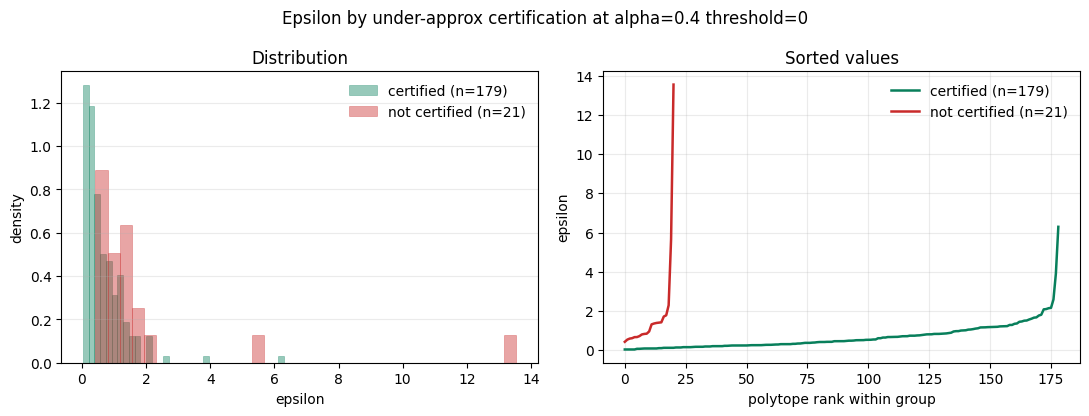

In [7]:
def build_epsilon_certification_df(
    volume_df: pd.DataFrame,
    approximation: str = 'under',
    certified_threshold: float = 0.0,
) -> pd.DataFrame:
    fraction_col = f'{approximation}_fraction'
    if fraction_col not in volume_df.columns:
        raise KeyError(f'Missing column {fraction_col!r}. Available columns: {list(volume_df.columns)}')

    out = volume_df[[
        'alpha', 'class_label', 'polytope_idx', 'eps', fraction_col,
    ]].rename(columns={fraction_col: 'retained_fraction'}).copy()
    out['certified'] = out['retained_fraction'].gt(float(certified_threshold))
    out['status'] = np.where(out['certified'], 'certified', 'not certified')
    out['approximation'] = approximation
    out['certified_threshold'] = float(certified_threshold)
    return out.sort_values(['alpha', 'certified', 'eps'], ignore_index=True)


def plot_epsilon_distribution_by_certification(
    epsilon_df: pd.DataFrame,
    alpha: float,
):
    alpha_df = epsilon_df[np.isclose(epsilon_df['alpha'].astype(float), float(alpha))].copy()
    if alpha_df.empty:
        raise ValueError(f'No epsilon rows found for alpha={alpha}. Available: {sorted(epsilon_df["alpha"].unique())}')

    summary = (
        alpha_df
        .groupby('status', observed=True)['eps']
        .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        .sort_index()
    )
    display(summary.round(6))

    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
    colors = {'certified': '#087F5B', 'not certified': '#C92A2A'}
    order = ['certified', 'not certified']

    for status in order:
        group = alpha_df[alpha_df['status'].eq(status)]
        if group.empty:
            continue
        color = colors[status]
        label = f'{status} (n={len(group)})'
        axes[0].hist(
            group['eps'], bins=35, alpha=0.42, density=True,
            color=color, edgecolor=color, linewidth=0.5, label=label,
        )
        sorted_eps = np.sort(group['eps'].to_numpy(dtype=float))
        axes[1].plot(
            np.arange(len(sorted_eps)), sorted_eps,
            color=color, linewidth=1.8, label=label,
        )

    approximation = alpha_df['approximation'].iloc[0]
    threshold = alpha_df['certified_threshold'].iloc[0]
    fig.suptitle(f'Epsilon by {approximation}-approx certification at alpha={alpha:g} threshold={threshold:g}')

    axes[0].set_title('Distribution')
    axes[0].set_xlabel('epsilon')
    axes[0].set_ylabel('density')
    axes[0].grid(True, axis='y', alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].set_title('Sorted values')
    axes[1].set_xlabel('polytope rank within group')
    axes[1].set_ylabel('epsilon')
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(frameon=False)

    fig.tight_layout()
    return alpha_df, fig, axes

EPS_ALPHA_TO_INSPECT = 0.4
EPS_CERTIFICATION_APPROXIMATION = 'under'
EPS_CERTIFIED_THRESHOLD = 0.0
EPSILON_DF = build_epsilon_certification_df(
    VOLUME_DF,
    approximation=EPS_CERTIFICATION_APPROXIMATION,
    certified_threshold=EPS_CERTIFIED_THRESHOLD,
)
EPS_ALPHA_DF, _, _ = plot_epsilon_distribution_by_certification(EPSILON_DF, EPS_ALPHA_TO_INSPECT)



### Epsilon Violin Plot Across Alphas

Distribution of selected epsilon values by certification status for all alpha values.


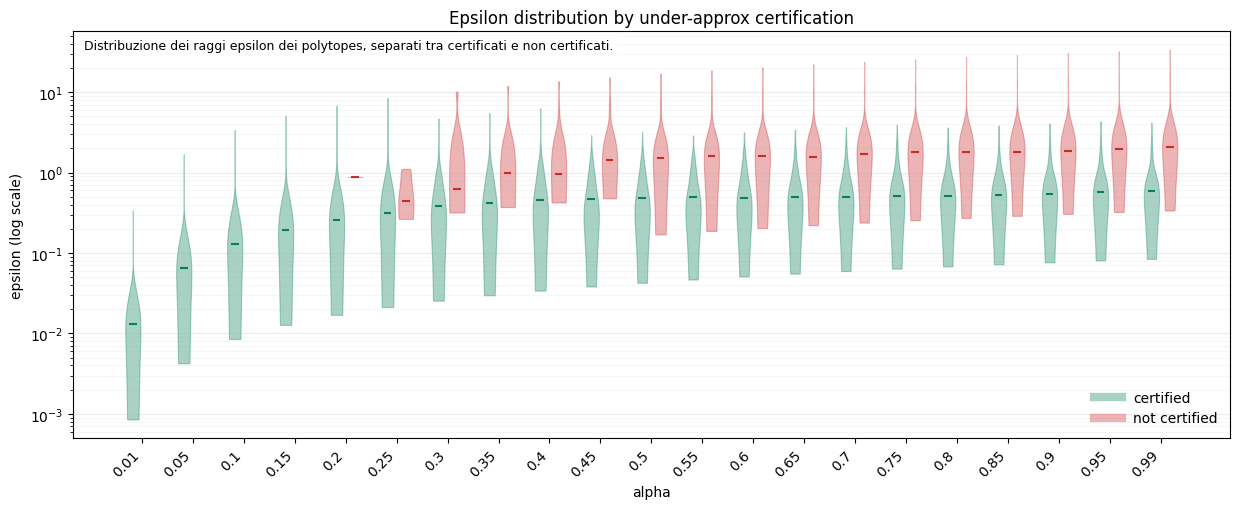

In [8]:
def plot_epsilon_violin_by_alpha_certification(
    volume_df: pd.DataFrame,
    alphas: list[float] | None = None,
    approximation: str = 'under',
    certified_threshold: float = 0.0,
):
    if alphas is None:
        alphas = [0.01] + [round(a, 2) for a in np.arange(0.05, 1.00, 0.05)] + [0.99]

    plot_df = build_epsilon_certification_df(
        volume_df,
        approximation=approximation,
        certified_threshold=certified_threshold,
    )
    alpha_values = [float(a) for a in alphas]
    plot_df = plot_df[plot_df['alpha'].isin(alpha_values)].copy()
    if plot_df.empty:
        raise ValueError('No rows available for the selected alphas.')

    status_order = ['certified', 'not certified']
    colors = {'certified': '#087F5B', 'not certified': '#C92A2A'}
    offsets = {'certified': -0.18, 'not certified': 0.18}

    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    legend_handles = []

    for status in status_order:
        data = []
        positions = []
        valid_alpha_indices = []
        for alpha_idx, alpha in enumerate(alpha_values):
            values = plot_df.loc[
                np.isclose(plot_df['alpha'].astype(float), alpha) & plot_df['status'].eq(status),
                'eps',
            ].to_numpy(dtype=float)
            values = values[np.isfinite(values) & (values > 0.0)]
            if len(values) == 0:
                continue
            data.append(values)
            positions.append(alpha_idx + offsets[status])
            valid_alpha_indices.append(alpha_idx)

        if not data:
            continue

        violins = ax.violinplot(
            data,
            positions=positions,
            widths=0.30,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )
        for body in violins['bodies']:
            body.set_facecolor(colors[status])
            body.set_edgecolor(colors[status])
            body.set_alpha(0.35)
            body.set_linewidth(0.8)
        violins['cmedians'].set_color(colors[status])
        violins['cmedians'].set_linewidth(1.5)
        legend_handles.append(plt.Line2D([0], [0], color=colors[status], linewidth=6, alpha=0.35, label=status))

    ax.set_title(f'Epsilon distribution by {approximation}-approx certification')
    ax.text(
        0.01, 0.98,
        'Distribuzione dei raggi epsilon dei polytopes, separati tra certificati e non certificati.',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=9,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 4},
    )
    ax.set_xlabel('alpha')
    ax.set_ylabel('epsilon (log scale)')
    ax.set_yscale('log')
    ax.set_xticks(range(len(alpha_values)))
    ax.set_xticklabels([f'{alpha:g}' for alpha in alpha_values], rotation=45, ha='right')
    ax.grid(True, axis='y', which='major', alpha=0.25)
    ax.grid(True, axis='y', which='minor', alpha=0.10)
    ax.legend(handles=legend_handles, frameon=False, loc='best')
    fig.tight_layout()
    return fig, ax

VIOLIN_ALPHAS = [0.01] + [round(a, 2) for a in np.arange(0.05, 1.00, 0.05)] + [0.99]
plot_epsilon_violin_by_alpha_certification(
    VOLUME_DF,
    alphas=VIOLIN_ALPHAS,
    approximation='under',
    certified_threshold=0.0,
);




## LP Feasibility Diagnostic

Check whether the certified halfspace intersection with the L1 ball is nonempty. This separates Monte Carlo zeros from truly empty certified polytopes.


In [9]:
from scipy.optimize import linprog


def center_satisfies_halfspaces(rec: dict, approximation: str, tol: float = 1e-9) -> tuple[bool, float]:
    A = np.asarray(rec[f'{approximation}_A'], dtype=np.float64)
    b = np.asarray(rec[f'{approximation}_b'], dtype=np.float64).reshape(-1)
    center = np.asarray(rec['center'], dtype=np.float64).reshape(-1)
    values = A @ center + b
    min_slack = float(np.min(values)) if values.size else np.inf
    return bool(min_slack >= -float(tol)), min_slack


def l1_halfspace_feasible(rec: dict, approximation: str, tol: float = 1e-8) -> dict:
    A = np.atleast_2d(np.asarray(rec[f'{approximation}_A'], dtype=np.float64))
    b = np.asarray(rec[f'{approximation}_b'], dtype=np.float64).reshape(-1)
    center = np.asarray(rec['center'], dtype=np.float64).reshape(-1)
    eps = float(rec['eps'])
    d = center.size

    # Variables are [z_0,...,z_{d-1}, u_0,...,u_{d-1}], with
    # u_i >= |z_i - center_i| and sum_i u_i <= eps.
    c = np.zeros(2 * d, dtype=np.float64)
    A_ub = []
    b_ub = []

    # z_i - u_i <= center_i
    lhs = np.zeros((d, 2 * d), dtype=np.float64)
    lhs[np.arange(d), np.arange(d)] = 1.0
    lhs[np.arange(d), d + np.arange(d)] = -1.0
    A_ub.append(lhs)
    b_ub.append(center)

    # -z_i - u_i <= -center_i
    lhs = np.zeros((d, 2 * d), dtype=np.float64)
    lhs[np.arange(d), np.arange(d)] = -1.0
    lhs[np.arange(d), d + np.arange(d)] = -1.0
    A_ub.append(lhs)
    b_ub.append(-center)

    # sum_i u_i <= eps
    lhs = np.zeros((1, 2 * d), dtype=np.float64)
    lhs[0, d:] = 1.0
    A_ub.append(lhs)
    b_ub.append(np.array([eps], dtype=np.float64))

    # A z + b >= 0  <=>  -A z <= b
    lhs = np.zeros((A.shape[0], 2 * d), dtype=np.float64)
    lhs[:, :d] = -A
    A_ub.append(lhs)
    b_ub.append(b)

    bounds = [(None, None)] * d + [(0.0, None)] * d
    res = linprog(
        c,
        A_ub=np.vstack(A_ub),
        b_ub=np.concatenate(b_ub),
        bounds=bounds,
        method='highs',
    )

    feasible = bool(res.success)
    max_violation = np.nan
    l1_distance = np.nan
    if feasible:
        z = np.asarray(res.x[:d], dtype=np.float64)
        slacks = A @ z + b
        l1_distance = float(np.abs(z - center).sum())
        max_violation = float(max(0.0, -np.min(slacks), l1_distance - eps))
        feasible = bool(max_violation <= float(tol))

    return {
        'lp_feasible': feasible,
        'lp_status': int(res.status),
        'lp_message': res.message,
        'lp_l1_distance_from_center': l1_distance,
        'lp_max_violation': max_violation,
    }


def build_feasibility_diagnostic_df(
    approximations_by_alpha: dict[float, list[dict]],
    volume_df: pd.DataFrame,
    alphas: list[float],
    approximations: tuple[str, ...] = ('under', 'over'),
) -> pd.DataFrame:
    volume_lookup = volume_df.set_index(['alpha', 'class_label', 'polytope_idx'])
    rows = []
    for alpha in alphas:
        records = approximations_by_alpha[float(alpha)]
        for rec in records:
            key = (float(alpha), int(rec['class_label']), int(rec['polytope_idx']))
            volume_row = volume_lookup.loc[key]
            for approximation in approximations:
                center_ok, center_min_slack = center_satisfies_halfspaces(rec, approximation)
                lp = l1_halfspace_feasible(rec, approximation)
                retained_fraction = float(volume_row[f'{approximation}_fraction'])
                rows.append({
                    'alpha': float(alpha),
                    'approximation': approximation,
                    'class_label': int(rec['class_label']),
                    'polytope_idx': int(rec['polytope_idx']),
                    'eps': float(rec['eps']),
                    'center_feasible': center_ok,
                    'center_min_slack': center_min_slack,
                    'lp_feasible': bool(lp['lp_feasible']),
                    'lp_status': int(lp['lp_status']),
                    'lp_l1_distance_from_center': lp['lp_l1_distance_from_center'],
                    'lp_max_violation': lp['lp_max_violation'],
                    'mc_retained_fraction': retained_fraction,
                    'mc_nonzero': retained_fraction > 0.0,
                })
    return pd.DataFrame(rows)


def summarize_feasibility_diagnostic(feasibility_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (alpha, approximation), group in feasibility_df.groupby(['alpha', 'approximation'], observed=True):
        center_fails_but_lp_feasible = (~group['center_feasible']) & group['lp_feasible']
        mc_zero_but_lp_feasible = (~group['mc_nonzero']) & group['lp_feasible']
        rows.append({
            'alpha': float(alpha),
            'approximation': approximation,
            'n_polytopes': int(len(group)),
            'center_feasible_%': 100.0 * float(group['center_feasible'].mean()),
            'lp_feasible_%': 100.0 * float(group['lp_feasible'].mean()),
            'mc_nonzero_%': 100.0 * float(group['mc_nonzero'].mean()),
            'center_fails_but_lp_feasible_%': 100.0 * float(center_fails_but_lp_feasible.mean()),
            'mc_zero_but_lp_feasible_%': 100.0 * float(mc_zero_but_lp_feasible.mean()),
            'median_eps': float(group['eps'].median()),
        })
    return pd.DataFrame(rows).sort_values(['alpha', 'approximation'], ignore_index=True)


FEASIBILITY_ALPHAS = [0.01, 0.25]
FEASIBILITY_DF = build_feasibility_diagnostic_df(
    APPROXIMATIONS_BY_ALPHA,
    VOLUME_DF,
    alphas=FEASIBILITY_ALPHAS,
    approximations=('under', 'over'),
)
FEASIBILITY_SUMMARY_DF = summarize_feasibility_diagnostic(FEASIBILITY_DF)
display(FEASIBILITY_SUMMARY_DF.round(4))




,alpha,approximation,n_polytopes,center_feasible_%,lp_feasible_%,mc_nonzero_%,center_fails_but_lp_feasible_%,mc_zero_but_lp_feasible_%,median_eps
0,0.01,over,200,100.0,100.0,100.0,0.0,0.0,0.013
1,0.01,under,200,100.0,100.0,100.0,0.0,0.0,0.013
2,0.25,over,200,100.0,100.0,100.0,0.0,0.0,0.324
3,0.25,under,200,88.0,99.5,97.5,11.5,2.0,0.324


## Local Network Nonlinearity Diagnostic

Measure how nonlinear the neural network is inside each certified L1 ball. The atlas still uses model-predicted labels; this block only analyzes the local behavior of the classifier around each polytope center.


In [10]:
NONLINEARITY_ALPHAS = [0.01, 0.10, 0.25, 0.50, 0.99]
NONLINEARITY_SAMPLES = 512
NONLINEARITY_BATCH_SIZE = 4096
RECOMPUTE_NONLINEARITY = False
NONLINEARITY_CACHE_PATH = ROOT / 'results/compas_certcf_alpha_ablation_nonlinearity_model_predictions.parquet'


def _torch_module_and_device():
    module = model.model.eval()
    device = torch.device(getattr(model, 'device', 'cpu'))
    return module, device


def model_logits_np(x_np: np.ndarray, batch_size: int = NONLINEARITY_BATCH_SIZE) -> np.ndarray:
    module, device = _torch_module_and_device()
    x_np = np.asarray(x_np, dtype=np.float32)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x_np), int(batch_size)):
            xb = torch.from_numpy(x_np[start:start + int(batch_size)]).to(device)
            outputs.append(module(xb).detach().cpu().numpy())
    return np.concatenate(outputs, axis=0)


def relu_activation_patterns_np(x_np: np.ndarray, batch_size: int = NONLINEARITY_BATCH_SIZE) -> np.ndarray:
    module, device = _torch_module_and_device()
    x_np = np.asarray(x_np, dtype=np.float32)
    patterns = []
    with torch.no_grad():
        for start in range(0, len(x_np), int(batch_size)):
            xb = torch.from_numpy(x_np[start:start + int(batch_size)]).to(device)
            out = xb
            batch_patterns = []
            for layer in module:
                out = layer(out)
                if isinstance(layer, torch.nn.ReLU):
                    batch_patterns.append((out > 0).detach().cpu().numpy())
            if not batch_patterns:
                raise RuntimeError('No ReLU layers found; activation-pattern nonlinearity is undefined.')
            patterns.append(np.concatenate(batch_patterns, axis=1))
    return np.concatenate(patterns, axis=0)


def margin_values_from_logits(logits: np.ndarray, class_label: int) -> np.ndarray:
    logits = np.asarray(logits, dtype=np.float64)
    class_label = int(class_label)
    class_scores = logits[:, class_label]
    other_logits = np.delete(logits, class_label, axis=1)
    other_scores = np.max(other_logits, axis=1)
    return class_scores - other_scores


def margin_and_gradient_at_center(center: np.ndarray, class_label: int) -> tuple[float, np.ndarray]:
    module, device = _torch_module_and_device()
    center_t = torch.tensor(np.asarray(center, dtype=np.float32)[None, :], device=device, requires_grad=True)
    logits = module(center_t)[0]
    class_label = int(class_label)
    other_idx = [idx for idx in range(int(logits.shape[0])) if idx != class_label]
    margin = logits[class_label] - torch.max(logits[other_idx])
    grad = torch.autograd.grad(margin, center_t, retain_graph=False, create_graph=False)[0]
    return float(margin.detach().cpu().item()), grad.detach().cpu().numpy().reshape(-1).astype(np.float64)


def compute_polytope_nonlinearity_metrics(
    rec: dict,
    n_samples: int = NONLINEARITY_SAMPLES,
    seed: int = RANDOM_SEED,
) -> dict:
    alpha = float(rec['alpha'])
    class_label = int(rec['class_label'])
    polytope_idx = int(rec['polytope_idx'])
    center = np.asarray(rec['center'], dtype=np.float64).reshape(-1)
    eps_i = float(rec['eps'])
    rng = np.random.default_rng(int(seed) + int(round(alpha * 10_000)) + 13 * class_label + 1009 * polytope_idx)
    samples = sample_l1_ball(center, eps_i, int(n_samples), rng).astype(np.float32)

    center_pattern = relu_activation_patterns_np(center[None, :])[0]
    sample_patterns = relu_activation_patterns_np(samples)
    pattern_diff = sample_patterns != center_pattern[None, :]
    activation_change_rate = float(np.mean(np.any(pattern_diff, axis=1)))
    activation_hamming_mean = float(np.mean(pattern_diff))
    activation_hamming_q95 = float(np.quantile(np.mean(pattern_diff, axis=1), 0.95))

    margin_center, grad = margin_and_gradient_at_center(center, class_label)
    sample_logits = model_logits_np(samples)
    sample_margins = margin_values_from_logits(sample_logits, class_label)
    linearized_margins = margin_center + (samples.astype(np.float64) - center[None, :]) @ grad
    lin_abs_error = np.abs(sample_margins - linearized_margins)
    margin_scale = float(np.mean(np.abs(sample_margins)) + 1e-12)

    return {
        'alpha': alpha,
        'class_label': class_label,
        'polytope_idx': polytope_idx,
        'eps': eps_i,
        'n_nonlinearity_samples': int(n_samples),
        'center_margin': float(margin_center),
        'grad_l2': float(np.linalg.norm(grad, ord=2)),
        'grad_l1': float(np.linalg.norm(grad, ord=1)),
        'activation_change_rate': activation_change_rate,
        'activation_hamming_mean': activation_hamming_mean,
        'activation_hamming_q95': activation_hamming_q95,
        'margin_linearization_mae': float(np.mean(lin_abs_error)),
        'margin_linearization_q95': float(np.quantile(lin_abs_error, 0.95)),
        'margin_linearization_max': float(np.max(lin_abs_error)),
        'margin_linearization_relative_mae': float(np.mean(lin_abs_error) / margin_scale),
        'sample_margin_mean': float(np.mean(sample_margins)),
        'sample_margin_min': float(np.min(sample_margins)),
        'sample_margin_negative_rate': float(np.mean(sample_margins < 0.0)),
    }


def compute_nonlinearity_df(
    approximations_by_alpha: dict[float, list[dict]],
    alphas: list[float],
    n_samples: int = NONLINEARITY_SAMPLES,
) -> pd.DataFrame:
    rows = []
    for alpha in alphas:
        alpha = float(alpha)
        records = approximations_by_alpha[alpha]
        print(f'nonlinearity alpha={alpha} records={len(records)} samples={n_samples}')
        for rec in records:
            rows.append(compute_polytope_nonlinearity_metrics(rec, n_samples=n_samples))
    return pd.DataFrame(rows)


def attach_volume_to_nonlinearity(nonlinearity_df: pd.DataFrame, volume_df: pd.DataFrame) -> pd.DataFrame:
    merge_cols = ['alpha', 'class_label', 'polytope_idx', 'eps']
    keep_cols = merge_cols + ['under_fraction', 'over_fraction', 'under_removed_fraction', 'over_removed_fraction']
    out = nonlinearity_df.merge(volume_df[keep_cols], on=merge_cols, how='left')
    out['under_certified'] = out['under_fraction'].gt(0.0)
    out['over_certified'] = out['over_fraction'].gt(0.0)
    return out

if NONLINEARITY_CACHE_PATH.exists() and not RECOMPUTE_NONLINEARITY:
    NONLINEARITY_DF = pd.read_parquet(NONLINEARITY_CACHE_PATH)
    print(f'loaded nonlinearity metrics from {NONLINEARITY_CACHE_PATH}')
else:
    NONLINEARITY_DF = compute_nonlinearity_df(
        APPROXIMATIONS_BY_ALPHA,
        alphas=NONLINEARITY_ALPHAS,
        n_samples=NONLINEARITY_SAMPLES,
    )
    NONLINEARITY_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    NONLINEARITY_DF.to_parquet(NONLINEARITY_CACHE_PATH, index=False)
    print(f'saved nonlinearity metrics to {NONLINEARITY_CACHE_PATH}')

NONLINEARITY_ANALYSIS_DF = attach_volume_to_nonlinearity(NONLINEARITY_DF, VOLUME_DF)

display(
    NONLINEARITY_ANALYSIS_DF
    .groupby('alpha')
    .agg(
        n_polytopes=('polytope_idx', 'size'),
        eps_median=('eps', 'median'),
        under_certified_pct=('under_certified', lambda s: 100.0 * s.mean()),
        activation_change_rate_mean=('activation_change_rate', 'mean'),
        activation_hamming_mean=('activation_hamming_mean', 'mean'),
        linearization_relative_mae_mean=('margin_linearization_relative_mae', 'mean'),
        sample_margin_negative_rate_mean=('sample_margin_negative_rate', 'mean'),
    )
    .round(5)
)



nonlinearity alpha=0.01 records=200 samples=512
nonlinearity alpha=0.1 records=200 samples=512
nonlinearity alpha=0.25 records=200 samples=512
nonlinearity alpha=0.5 records=200 samples=512
nonlinearity alpha=0.99 records=200 samples=512
saved nonlinearity metrics to /home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results/compas_certcf_alpha_ablation_nonlinearity_model_predictions.parquet


,n_polytopes,eps_median,under_certified_pct,activation_change_rate_mean,activation_hamming_mean,linearization_relative_mae_mean,sample_margin_negative_rate_mean
alpha,,,,,,,
0.01,200,0.01296,100.0,0.05031,0.00053,0.00003,0.00003
0.10,200,0.12959,100.0,0.35493,0.00491,0.00298,0.00350
0.25,200,0.32398,97.5,0.61790,0.01231,0.01574,0.01050
0.50,200,0.64796,77.5,0.80351,0.02455,0.03747,0.01920
0.99,200,1.28297,41.5,0.92543,0.04830,0.08400,0.03727


### Nonlinearity vs Certification

First visual check: do lower retained fractions align with stronger local nonlinearity?


/tmp/ipykernel_18259/733122169.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


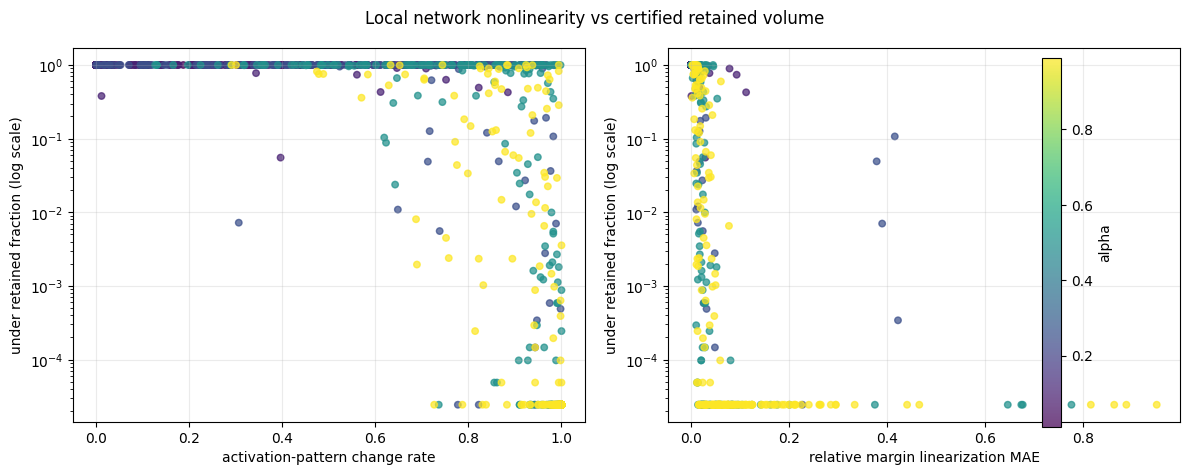

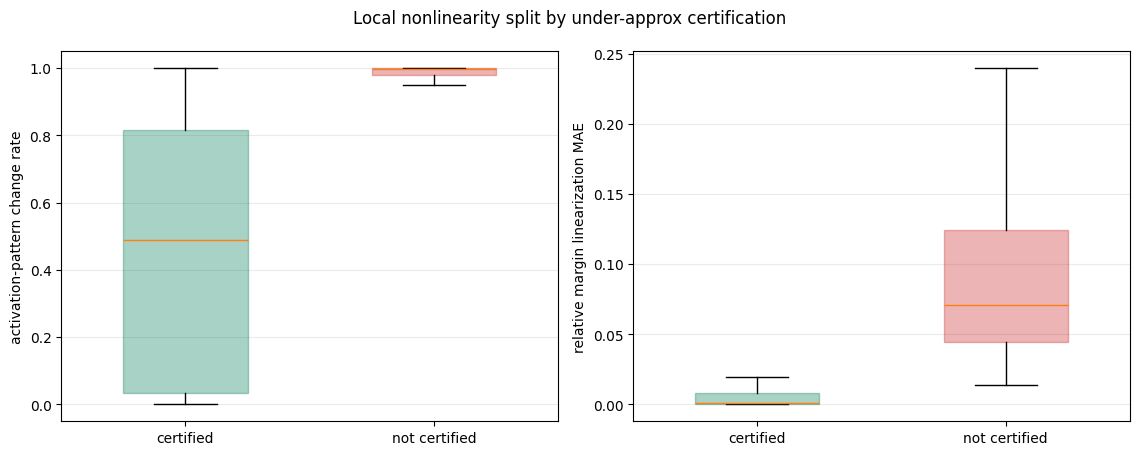

In [11]:
def plot_nonlinearity_vs_retained(nonlinearity_df: pd.DataFrame):
    plot_df = nonlinearity_df.copy()
    positive = plot_df.loc[plot_df['under_fraction'].gt(0.0), 'under_fraction']
    floor = max(float(positive.min()) * 0.5, 1e-8) if len(positive) else 1e-8
    plot_df['under_fraction_for_plot'] = plot_df['under_fraction'].clip(lower=floor)

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
    sc0 = axes[0].scatter(
        plot_df['activation_change_rate'],
        plot_df['under_fraction_for_plot'],
        c=plot_df['alpha'],
        cmap='viridis',
        s=22,
        alpha=0.72,
    )
    axes[0].set_xlabel('activation-pattern change rate')
    axes[0].set_ylabel('under retained fraction (log scale)')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.25)

    sc1 = axes[1].scatter(
        plot_df['margin_linearization_relative_mae'],
        plot_df['under_fraction_for_plot'],
        c=plot_df['alpha'],
        cmap='viridis',
        s=22,
        alpha=0.72,
    )
    axes[1].set_xlabel('relative margin linearization MAE')
    axes[1].set_ylabel('under retained fraction (log scale)')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.25)

    cbar = fig.colorbar(sc1, ax=axes, fraction=0.035, pad=0.03)
    cbar.set_label('alpha')
    fig.suptitle('Local network nonlinearity vs certified retained volume')
    fig.tight_layout()
    return fig, axes


def plot_nonlinearity_by_certification(nonlinearity_df: pd.DataFrame):
    plot_df = nonlinearity_df.copy()
    plot_df['status'] = np.where(plot_df['under_certified'], 'certified', 'not certified')
    metrics = [
        ('activation_change_rate', 'activation-pattern change rate'),
        ('margin_linearization_relative_mae', 'relative margin linearization MAE'),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
    colors = {'certified': '#087F5B', 'not certified': '#C92A2A'}
    for ax, (col, label) in zip(axes, metrics):
        data = []
        positions = []
        for idx, status in enumerate(['certified', 'not certified']):
            values = plot_df.loc[plot_df['status'].eq(status), col].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue
            data.append(values)
            positions.append(idx)
        bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showfliers=False)
        for patch, status in zip(bp['boxes'], ['certified', 'not certified']):
            patch.set_facecolor(colors[status])
            patch.set_alpha(0.35)
            patch.set_edgecolor(colors[status])
        ax.set_xticks(positions)
        ax.set_xticklabels(['certified', 'not certified'][:len(positions)])
        ax.set_ylabel(label)
        ax.grid(True, axis='y', alpha=0.25)
    fig.suptitle('Local nonlinearity split by under-approx certification')
    fig.tight_layout()
    return fig, axes

plot_nonlinearity_vs_retained(NONLINEARITY_ANALYSIS_DF);
plot_nonlinearity_by_certification(NONLINEARITY_ANALYSIS_DF);



### Does Nonlinearity Predict Certification Beyond Epsilon?

Compare simple predictive models for under-approx certification: epsilon only vs epsilon plus local network nonlinearity.


,model,features,auc_not_certified,balanced_accuracy,accuracy,log_loss,n_features
0,log_eps + activation + lin_error,"log_eps, activation_change_rate, margin_linear...",0.9802,0.9346,0.915,0.2291,3
1,log_eps + lin_error,"log_eps, margin_linearization_relative_mae",0.9789,0.9340,0.926,0.2581,2
2,log_eps + hamming,"log_eps, activation_hamming_mean",0.9773,0.9077,0.914,0.1946,2
3,log_eps + activation_change,"log_eps, activation_change_rate",0.9672,0.8920,0.864,0.2517,2
4,log_eps,log_eps,0.9426,0.8759,0.857,0.3173,1


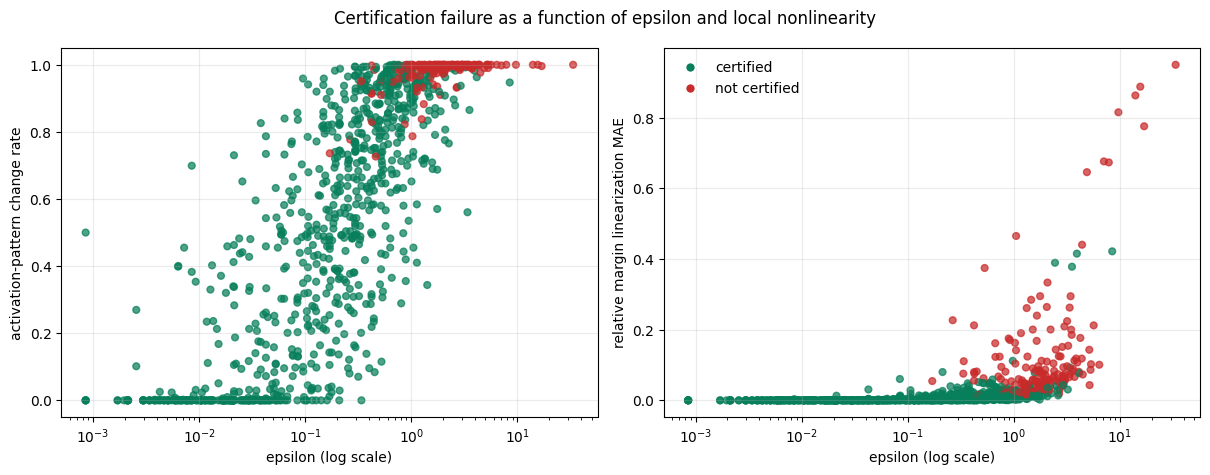

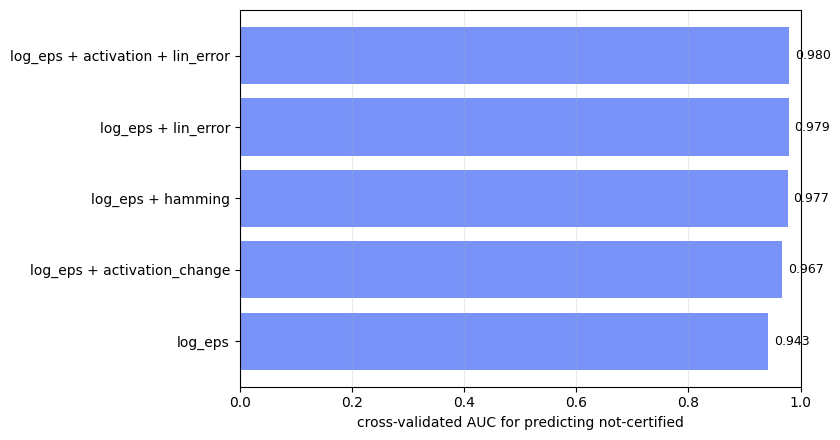

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def build_certification_prediction_df(nonlinearity_df: pd.DataFrame) -> pd.DataFrame:
    df = nonlinearity_df.copy()
    df = df[np.isfinite(df['eps']) & df['eps'].gt(0.0)].copy()
    df['log_eps'] = np.log(df['eps'].astype(float))
    df['not_certified'] = (~df['under_certified']).astype(int)
    return df


def evaluate_certification_predictors(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    feature_sets = {
        'log_eps': ['log_eps'],
        'log_eps + activation_change': ['log_eps', 'activation_change_rate'],
        'log_eps + hamming': ['log_eps', 'activation_hamming_mean'],
        'log_eps + lin_error': ['log_eps', 'margin_linearization_relative_mae'],
        'log_eps + activation + lin_error': [
            'log_eps',
            'activation_change_rate',
            'margin_linearization_relative_mae',
        ],
    }
    y = df['not_certified'].to_numpy(dtype=int)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rows = []
    pred_proba_by_model = {}

    for name, cols in feature_sets.items():
        X = df[cols].to_numpy(dtype=float)
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED),
        )
        proba = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
        pred = (proba >= 0.5).astype(int)
        pred_proba_by_model[name] = proba
        rows.append({
            'model': name,
            'features': ', '.join(cols),
            'auc_not_certified': roc_auc_score(y, proba),
            'balanced_accuracy': balanced_accuracy_score(y, pred),
            'accuracy': accuracy_score(y, pred),
            'log_loss': log_loss(y, proba),
            'n_features': len(cols),
        })

    return pd.DataFrame(rows).sort_values('auc_not_certified', ascending=False, ignore_index=True), pred_proba_by_model


def plot_epsilon_nonlinearity_certification(df: pd.DataFrame):
    colors = np.where(df['under_certified'], '#087F5B', '#C92A2A')
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8))

    axes[0].scatter(
        df['eps'],
        df['activation_change_rate'],
        c=colors,
        s=24,
        alpha=0.72,
    )
    axes[0].set_xscale('log')
    axes[0].set_xlabel('epsilon (log scale)')
    axes[0].set_ylabel('activation-pattern change rate')
    axes[0].grid(True, alpha=0.25)

    axes[1].scatter(
        df['eps'],
        df['margin_linearization_relative_mae'],
        c=colors,
        s=24,
        alpha=0.72,
    )
    axes[1].set_xscale('log')
    axes[1].set_xlabel('epsilon (log scale)')
    axes[1].set_ylabel('relative margin linearization MAE')
    axes[1].grid(True, alpha=0.25)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#087F5B', markersize=7, label='certified'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#C92A2A', markersize=7, label='not certified'),
    ]
    axes[1].legend(handles=handles, frameon=False, loc='best')
    fig.suptitle('Certification failure as a function of epsilon and local nonlinearity')
    fig.tight_layout()
    return fig, axes


def plot_predictive_model_scores(scores_df: pd.DataFrame):
    plot_df = scores_df.sort_values('auc_not_certified', ascending=True)
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.barh(plot_df['model'], plot_df['auc_not_certified'], color='#4C6EF5', alpha=0.75)
    ax.set_xlabel('cross-validated AUC for predicting not-certified')
    ax.set_xlim(0.0, 1.0)
    ax.grid(True, axis='x', alpha=0.25)
    for idx, value in enumerate(plot_df['auc_not_certified']):
        ax.text(value + 0.01, idx, f'{value:.3f}', va='center', fontsize=9)
    fig.tight_layout()
    return fig, ax

CERTIFICATION_PREDICTION_DF = build_certification_prediction_df(NONLINEARITY_ANALYSIS_DF)
CERTIFICATION_PREDICTOR_SCORES_DF, CERTIFICATION_PREDICTOR_PROBA = evaluate_certification_predictors(
    CERTIFICATION_PREDICTION_DF
)

display(CERTIFICATION_PREDICTOR_SCORES_DF.round(4))
plot_epsilon_nonlinearity_certification(CERTIFICATION_PREDICTION_DF);
plot_predictive_model_scores(CERTIFICATION_PREDICTOR_SCORES_DF);



## Volume Summary


In [16]:
def volume_summary(volume_df: pd.DataFrame) -> pd.DataFrame:
    long_df = volume_df.melt(
        id_vars=['alpha', 'class_label', 'polytope_idx', 'eps', 'dimension', 'n_samples'],
        value_vars=['log_under_volume', 'log_over_volume'],
        var_name='approximation',
        value_name='log_volume',
    )
    long_df['approximation'] = long_df['approximation'].map({
        'log_under_volume': 'under',
        'log_over_volume': 'over',
    })
    long_df['log10_volume'] = long_df['log_volume'] / math.log(10.0)

    summary = (
        long_df
        .assign(finite=lambda d: np.isfinite(d['log_volume']))
        .groupby(['alpha', 'approximation'], observed=True)
        .agg(
            n_polytopes=('polytope_idx', 'size'),
            nonzero_pct=('finite', lambda s: 100.0 * float(s.mean())),
            log10_volume_median=('log10_volume', 'median'),
            log10_volume_q10=('log10_volume', lambda s: np.nanquantile(s.replace([np.inf, -np.inf], np.nan), 0.10)),
            log10_volume_q90=('log10_volume', lambda s: np.nanquantile(s.replace([np.inf, -np.inf], np.nan), 0.90)),
        )
        .reset_index()
        .sort_values(['alpha', 'approximation'], ignore_index=True)
    )
    return long_df, summary

VOLUME_LONG_DF, VOLUME_SUMMARY_DF = volume_summary(VOLUME_DF)


## Volume Removed by LiRPA Halfspaces


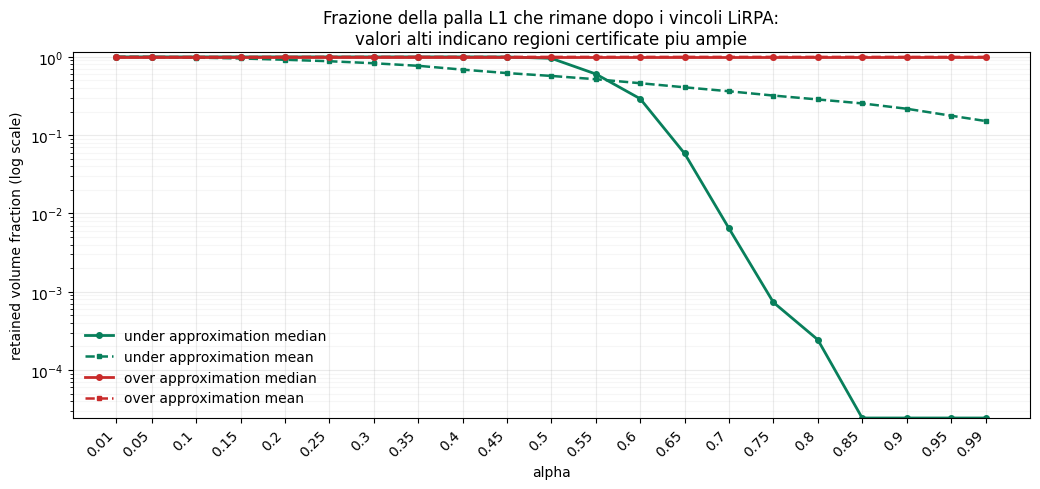

In [17]:
def ensure_removed_fraction_long_df(volume_long_df: pd.DataFrame) -> pd.DataFrame:
    if 'removed_fraction' in volume_long_df.columns:
        out = volume_long_df.copy()
    elif 'retained_fraction' in volume_long_df.columns:
        out = volume_long_df.copy()
        out['removed_fraction'] = 1.0 - out['retained_fraction'].clip(0.0, 1.0)
    else:
        required = {
            'alpha', 'class_label', 'polytope_idx', 'eps', 'dimension', 'n_samples',
            'under_fraction', 'over_fraction', 'log_under_volume', 'log_over_volume', 'log_ball_volume',
        }
        if 'VOLUME_DF' not in globals() or not required.issubset(VOLUME_DF.columns):
            raise KeyError(
                "removed_fraction is missing and cannot be reconstructed from VOLUME_DF. "
                "Re-run the Build Atlases and Estimate Volumes cell."
            )

        def _make_side(prefix: str) -> pd.DataFrame:
            retained_col = f'{prefix}_fraction'
            removed_col = f'{prefix}_removed_fraction'
            log_volume_col = f'log_{prefix}_volume'
            log_removed_col = f'log_{prefix}_removed_volume'
            side = VOLUME_DF[[
                'alpha', 'class_label', 'polytope_idx', 'eps', 'dimension', 'n_samples',
                retained_col, log_volume_col, 'log_ball_volume',
            ]].rename(columns={retained_col: 'retained_fraction', log_volume_col: 'log_volume'})
            if removed_col in VOLUME_DF.columns:
                side['removed_fraction'] = VOLUME_DF[removed_col].to_numpy(dtype=float)
            else:
                side['removed_fraction'] = 1.0 - side['retained_fraction'].clip(0.0, 1.0)
            if log_removed_col in VOLUME_DF.columns:
                side['log_removed_volume'] = VOLUME_DF[log_removed_col].to_numpy(dtype=float)
            else:
                side['log_removed_volume'] = side['log_ball_volume'] + np.log(side['removed_fraction'].clip(lower=0.0))
                side.loc[side['removed_fraction'].le(0.0), 'log_removed_volume'] = -np.inf
            side['approximation'] = prefix
            return side.drop(columns='log_ball_volume')

        out = pd.concat([_make_side('under'), _make_side('over')], ignore_index=True)
        out['log10_volume'] = out['log_volume'] / math.log(10.0)
        out['log10_removed_volume'] = out['log_removed_volume'] / math.log(10.0)

    if 'retained_fraction' not in out.columns:
        out['retained_fraction'] = 1.0 - out['removed_fraction'].clip(0.0, 1.0)
    return out


def plot_removed_fraction_distributions(volume_long_df: pd.DataFrame):
    plot_df = ensure_removed_fraction_long_df(volume_long_df).copy()
    plot_df['retained_fraction'] = plot_df['retained_fraction'].clip(0.0, 1.0)

    positive = plot_df.loc[plot_df['retained_fraction'].gt(0.0), 'retained_fraction']
    floor = max(float(positive.min()) * 0.5, 1e-8) if len(positive) else 1e-8
    plot_df['retained_fraction_for_plot'] = plot_df['retained_fraction'].clip(lower=floor)

    colors = {'under': '#087F5B', 'over': '#C92A2A'}
    labels = {'under': 'under approximation', 'over': 'over approximation'}

    fig, ax = plt.subplots(figsize=(10.5, 5.0))
    for approx in ['under', 'over']:
        side = plot_df[plot_df['approximation'].eq(approx)]
        stats = (
            side.groupby('alpha')['retained_fraction_for_plot']
            .agg(mean='mean', median='median')
            .reset_index()
            .sort_values('alpha')
        )
        x = stats['alpha'].to_numpy(dtype=float)
        mean = stats['mean'].to_numpy(dtype=float)
        median = stats['median'].to_numpy(dtype=float)
        ax.plot(
            x, median, color=colors[approx], marker='o', markersize=4, linewidth=2.0,
            label=f'{labels[approx]} median',
        )
        ax.plot(
            x, mean, color=colors[approx], marker='s', markersize=3.5, linewidth=1.8,
            linestyle='--', label=f'{labels[approx]} mean',
        )

    ax.set_title(
        'Frazione della palla L1 che rimane dopo i vincoli LiRPA:\n'
        'valori alti indicano regioni certificate piu ampie'
    )
    ax.set_xlabel('alpha')
    ax.set_ylabel('retained volume fraction (log scale)')
    ax.set_yscale('log')
    ax.set_ylim(floor, 1.15)
    ax.set_xticks(sorted(plot_df['alpha'].unique()))
    ax.set_xticklabels([f'{alpha:g}' for alpha in sorted(plot_df['alpha'].unique())], rotation=45, ha='right')
    ax.grid(True, which='major', axis='both', alpha=0.25)
    ax.grid(True, which='minor', axis='y', alpha=0.10)
    ax.legend(frameon=False, loc='best')
    fig.tight_layout()
    return fig, ax

VOLUME_LONG_DF = ensure_removed_fraction_long_df(VOLUME_LONG_DF)
plot_removed_fraction_distributions(VOLUME_LONG_DF);







## Volume Distribution Plot


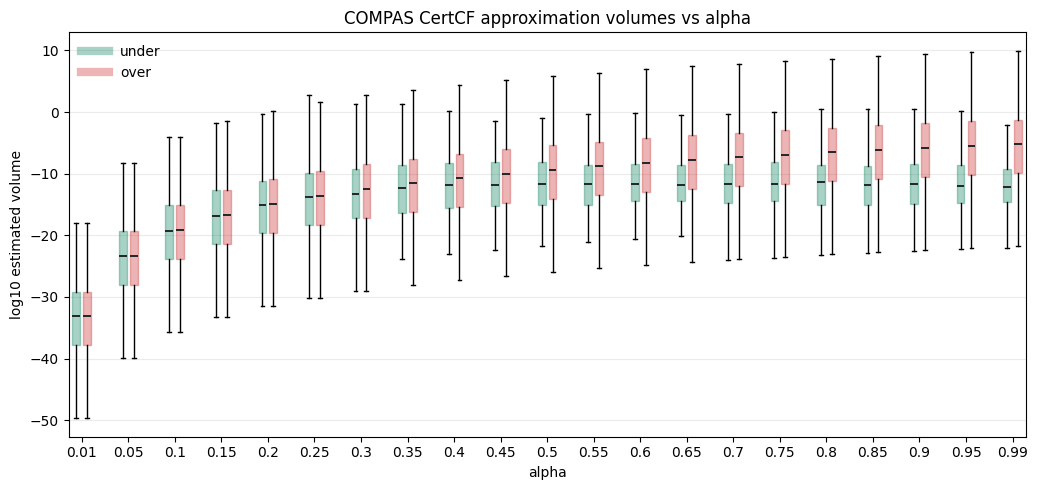

In [14]:
def plot_volume_distributions(volume_long_df: pd.DataFrame):
    plot_df = volume_long_df[np.isfinite(volume_long_df['log10_volume'])].copy()
    alphas = sorted(plot_df['alpha'].unique())
    approximations = ['under', 'over']
    colors = {'under': '#087F5B', 'over': '#C92A2A'}

    fig, ax = plt.subplots(figsize=(10.5, 5.0))
    positions = []
    data = []
    box_colors = []
    tick_positions = []
    tick_labels = []

    for alpha_idx, alpha in enumerate(alphas):
        base = alpha_idx * 3.0
        tick_positions.append(base + 0.35)
        tick_labels.append(f'{alpha:g}')
        for approx_idx, approx in enumerate(approximations):
            pos = base + approx_idx * 0.7
            values = plot_df.loc[
                plot_df['alpha'].eq(alpha) & plot_df['approximation'].eq(approx),
                'log10_volume',
            ].to_numpy(dtype=float)
            positions.append(pos)
            data.append(values)
            box_colors.append(colors[approx])

    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
        patch.set_edgecolor(color)
    for median in bp['medians']:
        median.set_color('#212529')
        median.set_linewidth(1.4)

    for approx in approximations:
        ax.plot([], [], color=colors[approx], linewidth=6, alpha=0.35, label=approx)

    ax.set_title('COMPAS CertCF approximation volumes vs alpha')
    ax.set_xlabel('alpha')
    ax.set_ylabel('log10 estimated volume')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

plot_volume_distributions(VOLUME_LONG_DF);
